# Data Ingestion

Mengubah data pdf ke dalam format csv

In [1]:
import pandas as pd
from src.data_ingestion import pojk_ke_df

input_pdf_path = "data/POJK_22-2023.pdf" 
output_csv_path = "data/pojk22_raw_extracted.csv"
df_pojk = pojk_ke_df(input_pdf_path)

if df_pojk is not None:
    df_pojk.to_csv(output_csv_path, index=False)
    print(f"{len(df_pojk)} pasal berhasil diekstrak.")

df_pojk.head()

125 pasal berhasil diekstrak.


,Entitas_Hukum,Teks_Mentah
0,Pasal 1,Dalam Peraturan Otoritas Jasa Keuangan ini yan...
1,Pasal 2,PUJK sebagaimana dimaksud dalam Pasal 1 angka ...
2,Pasal 3,(1) PUJK dalam menyelenggarakan kegiatan usaha...
3,Pasal 4,(1) PUJK wajib beriktikad baik dalam melakukan...
4,Pasal 5,(1) PUJK dilarang menyetujui permohonan penggu...


# Exploratory Data Analysis

Pada tahap ini, dilakukan eksplorasi terhadap dataset teks mentah untuk memahami karakteristik struktural sebelum masuk ke tahap pemodelan. 

**Deskripsi Dataset:**
*   **Sumber Data:** Dokumen Peraturan Otoritas Jasa Keuangan (POJK) Republik Indonesia Nomor 22 Tahun 2023 tentang Pelindungan Konsumen dan Masyarakat di Sektor Jasa Keuangan.
*   **Format Data:** Teks tabular (CSV) hasil ekstraksi otomatis dari dokumen PDF resmi menggunakan teknik *sequential validation regex*.
*   **Jumlah Data:** Dataset terdiri dari 125 baris data, di mana setiap baris merepresentasikan satu pasal utuh (Pasal 1 hingga Pasal 125).
*   **Label/Topik:** Dataset ini tidak berlabel (*unlabeled*), sehingga sangat relevan untuk dieksplorasi menggunakan pendekatan *unsupervised learning* (*Topic Modeling*).

In [2]:
import pandas as pd

import seaborn as sns

sns.set_theme(style="whitegrid")

df_eda = pd.read_csv("data/pojk22_raw_extracted.csv")

df_eda['Jumlah_Karakter'] = df_eda['Teks_Mentah'].apply(len)
df_eda['Jumlah_Kata'] = df_eda['Teks_Mentah'].apply(lambda x: len(str(x).split()))

display(df_eda.head())

,Entitas_Hukum,Teks_Mentah,Jumlah_Karakter,Jumlah_Kata
0,Pasal 1,Dalam Peraturan Otoritas Jasa Keuangan ini yan...,6530,828
1,Pasal 2,PUJK sebagaimana dimaksud dalam Pasal 1 angka ...,939,125
2,Pasal 3,(1) PUJK dalam menyelenggarakan kegiatan usaha...,1274,172
3,Pasal 4,(1) PUJK wajib beriktikad baik dalam melakukan...,2066,271
4,Pasal 5,(1) PUJK dilarang menyetujui permohonan penggu...,2065,288


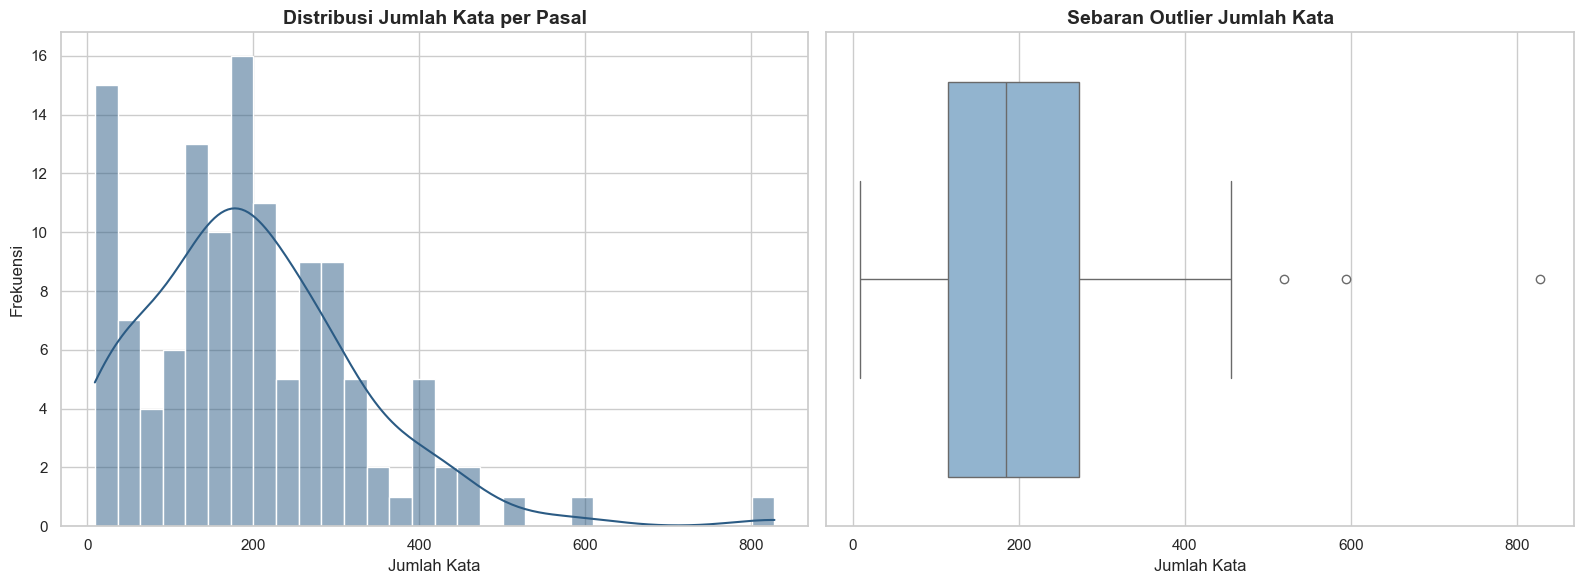


=== Statistik Deskriptif Jumlah Kata ===
count    125.000000
mean     199.408000
std      133.276882
min        9.000000
25%      115.000000
50%      184.000000
75%      273.000000
max      828.000000
Name: Jumlah_Kata, dtype: float64


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_eda['Jumlah_Kata'], bins=30, kde=True, color='#2b5b84', ax=ax[0])
ax[0].set_title('Distribusi Jumlah Kata per Pasal', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Jumlah Kata', fontsize=12)
ax[0].set_ylabel('Frekuensi', fontsize=12)

sns.boxplot(x=df_eda['Jumlah_Kata'], color='#88b5d9', ax=ax[1])
ax[1].set_title('Sebaran Outlier Jumlah Kata', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Jumlah Kata', fontsize=12)

plt.tight_layout()
plt.show()
print("\n=== Statistik Deskriptif Jumlah Kata ===")
print(df_eda['Jumlah_Kata'].describe())

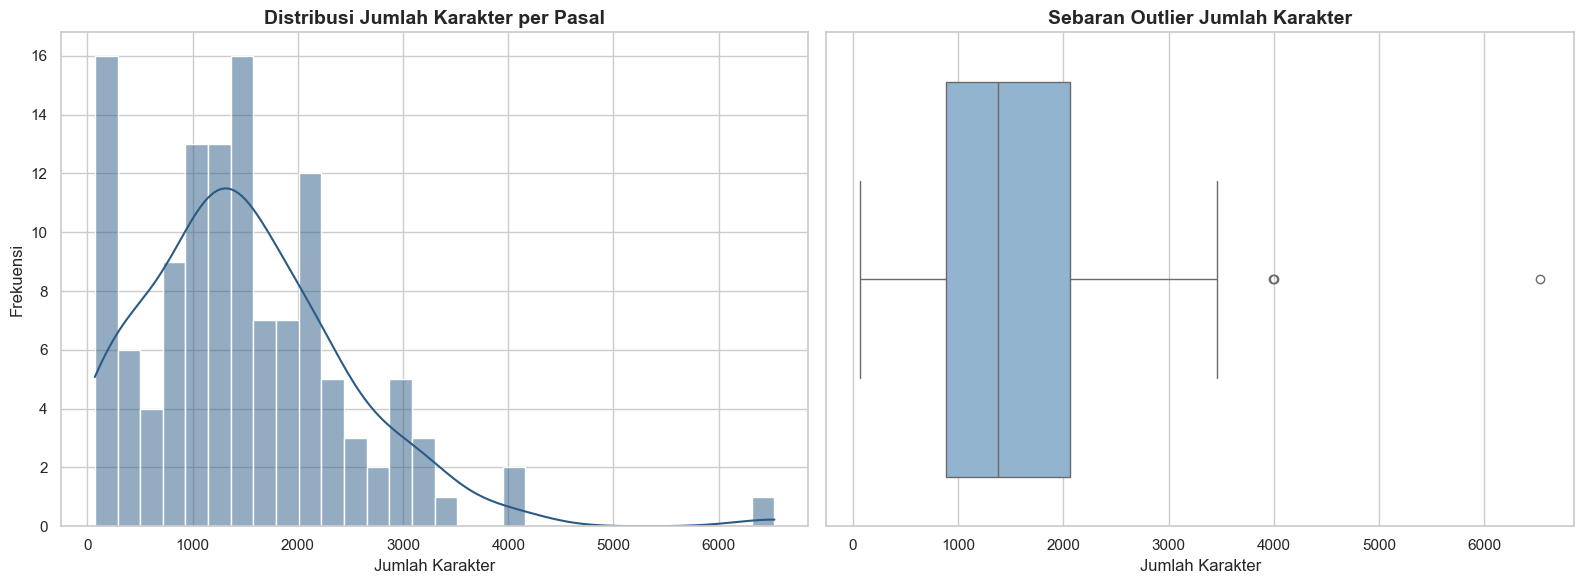


=== Statistik Deskriptif Jumlah Karakter ===
count     125.000000
mean     1498.832000
std      1001.314811
min        70.000000
25%       882.000000
50%      1378.000000
75%      2066.000000
max      6530.000000
Name: Jumlah_Karakter, dtype: float64


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_eda['Jumlah_Karakter'], bins=30, kde=True, color='#2b5b84', ax=ax[0])
ax[0].set_title('Distribusi Jumlah Karakter per Pasal', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Jumlah Karakter', fontsize=12)
ax[0].set_ylabel('Frekuensi', fontsize=12)

sns.boxplot(x=df_eda['Jumlah_Karakter'], color='#88b5d9', ax=ax[1])
ax[1].set_title('Sebaran Outlier Jumlah Karakter', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Jumlah Karakter', fontsize=12)

plt.tight_layout()
plt.show()
print("\n=== Statistik Deskriptif Jumlah Karakter ===")
print(df_eda['Jumlah_Karakter'].describe())

**Analisis Distribusi dan Insight Awal:**
1.  **Variansi Panjang Teks:** Berdasarkan visualisasi distribusi di atas, mayoritas pasal memiliki panjang teks yang moderat (rata-rata 199 kata). Kurva distribusi menunjukkan kemiringan positif (*right-skewed*).
2.  **Kehadiran Outlier:** Terdapat beberapa *outlier* ekstrem dengan jumlah kata yang sangat masif (mencapai lebih dari 800 kata). Pasal-pasal panjang ini umumnya merupakan "Ketentuan Umum" (seperti Pasal 1 yang memuat banyak definisi) atau pasal peralihan yang kompleks.
3.  **Implikasi terhadap Modeling NLP:** 
    *   Variansi panjang teks yang tinggi ini mengindikasikan perlunya proses *preprocessing* yang ketat. 
    *   Untuk *Topic Modeling* klasikal seperti LDA, pasal yang terlalu pendek mungkin kehilangan konteks (*sparsity*), sementara pasal yang terlalu panjang bisa mendominasi distribusi probabilitas kata. 
    *   Oleh karena itu, penggunaan *contextual embedding* (seperti IndoBERT pada BERTopic) nantinya diprediksi akan jauh lebih unggul dalam menangkap makna semantik dari pasal-pasal ini dibandingkan sekadar mengandalkan frekuensi kata (TF-IDF), karena model berbasis *transformer* lebih tangguh menghadapi rentang panjang konteks yang dinamis.

C:\Users\Asus\AppData\Local\Temp\ipykernel_16512\2482636864.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata/Frasa', data=df_freq, palette='magma')


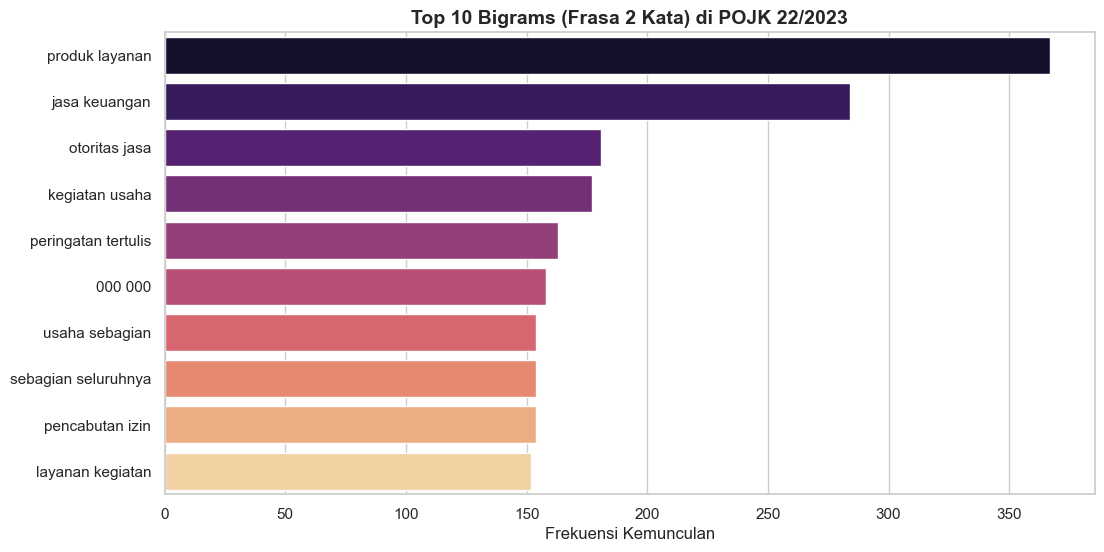

C:\Users\Asus\AppData\Local\Temp\ipykernel_16512\2482636864.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata/Frasa', data=df_freq, palette='magma')


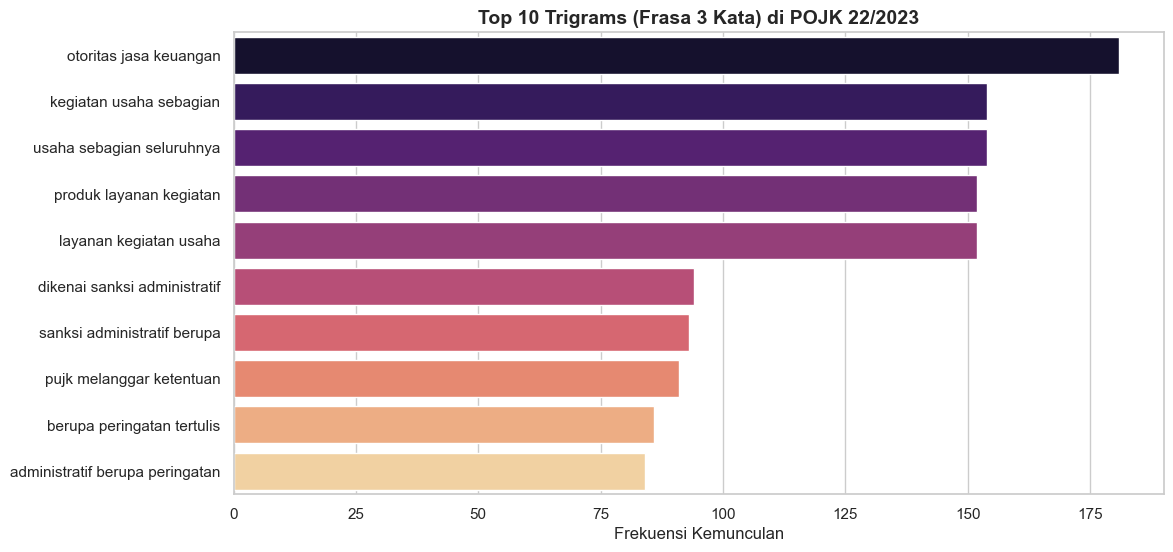

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

stop_words_eda = ['yang', 'dan', 'atau', 'dengan', 'bahwa', 'untuk', 'pada', 'dalam', 
                  'dari', 'serta', 'kepada', 'oleh', 'sebagaimana', 'dimaksud', 'ayat', 
                  'pasal', 'huruf', 'angka', 'nomor', 'tahun', 'tentang', 'terkait', 
                  'di', 'ini', 'itu', 'tersebut', 'tidak', 'dapat', 'secara', 'lain',
                  'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 
                  'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

def plot_top_ngrams(corpus, n=10, ngram_range=(1, 1), title=""):
    vec = CountVectorizer(stop_words=stop_words_eda, ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    df_freq = pd.DataFrame(words_freq[:n], columns=['Kata/Frasa', 'Frekuensi'])
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Frekuensi', y='Kata/Frasa', data=df_freq, palette='magma')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frekuensi Kemunculan', fontsize=12)
    plt.ylabel('')
    plt.show()

plot_top_ngrams(df_eda['Teks_Mentah'], n=10, ngram_range=(2, 2), title='Top 10 Bigrams (Frasa 2 Kata) di POJK 22/2023')

plot_top_ngrams(df_eda['Teks_Mentah'], n=10, ngram_range=(3, 3), title='Top 10 Trigrams (Frasa 3 Kata) di POJK 22/2023')

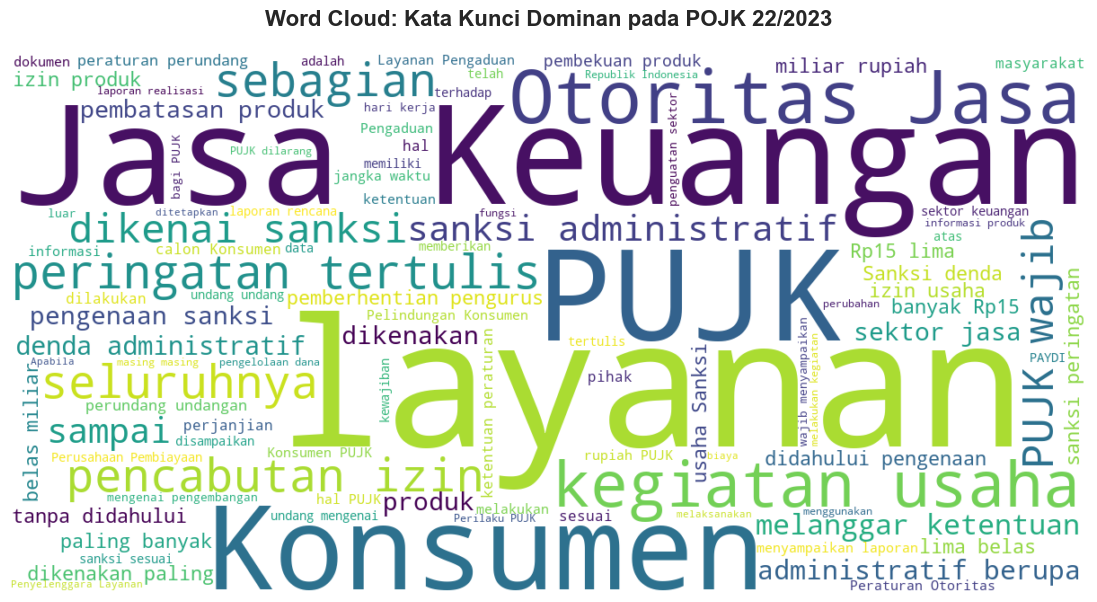

In [7]:
from wordcloud import WordCloud

text_corpus = " ".join(df_eda['Teks_Mentah'].dropna())

wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white',
    colormap='viridis', 
    stopwords=stop_words_eda,
    max_words=100,
    contour_width=1,
    contour_color='steelblue'
).generate(text_corpus)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Kata Kunci Dominan pada POJK 22/2023', fontsize=16, fontweight='bold', pad=20)
plt.show()

Berdasarkan hasil analisis N-grams dan WordCloud ditemukan kata paling sering muncul, yaitu:
1. Frasa 1 Kata: Layanan, Keuangan, Konsumen
2. Frasa 2 Kata: Produk Layanan, Jasa Keuangan, Otoritas Jasa
3. Frasa 3 Kata: Otoritas Jasa Keuangan, Kegiatan Usaha Sebagian, Usaha Sebagian Seluruhnya

# Preprocessing

Untuk mengakomodasi dua jenis model yang berbeda (LDA dan BERTopic), diterapkan 2 cara dalam pembersihan data:
- Untuk model LDA (statistik): Melakukan pembersihan total termasuk Stopword Removal dan Stemming menggunakan Sastrawi. Hal ini bertujuan untuk mereduksi kata ke bentuk dasar agar model statistik dapat menghitung probabilitas dengan lebih akurat.
- Untuk model BERTopic (Semantik): Hanya melakukan pembersihan noise dasar tanpa stemming. Hal ini dilakukan untuk menjaga konteks dan makna kata yang dibutuhkan oleh model Deep Learning (IndoBERT).

In [5]:
from src.preprocessing import node_preprocessing

df_clean = node_preprocessing(
    input_path="data/pojk22_raw_extracted.csv", 
    output_path="data/pojk22_cleaned.csv"
)

display(df_clean[['Teks_Mentah', 'Teks_Bersih_BERT', 'Teks_Bersih_LDA']].head())

Membaca data dari: data/pojk22_raw_extracted.csv
Berhasil! Data bersih disimpan di: data/pojk22_cleaned.csv


,Teks_Mentah,Teks_Bersih_BERT,Teks_Bersih_LDA
0,Dalam Peraturan Otoritas Jasa Keuangan ini yan...,peraturan otoritas jasa keuangan lembaga jasa ...,atur otoritas jasa uang lembaga jasa uang lanj...
1,PUJK sebagaimana dimaksud dalam Pasal 1 angka ...,pujk terdiri atas ljk meliputi bank umum bank ...,pujk diri atas ljk liput bank umum bank ekonom...
2,(1) PUJK dalam menyelenggarakan kegiatan usaha...,pujk menyelenggarakan kegiatan usaha wajib men...,pujk selenggara giat usaha wajib terap prinsip...
3,(1) PUJK wajib beriktikad baik dalam melakukan...,pujk wajib beriktikad baik melakukan kegiatan ...,pujk wajib iktikad baik laku giat usaha beri p...
4,(1) PUJK dilarang menyetujui permohonan penggu...,pujk dilarang menyetujui permohonan penggunaan...,pujk larang tuju mohon guna produk layan pihak...


# Representation

Tahap ini mengubah teks hasil preprocessing menjadi representasi numerik (vektor). Dilakukan ekstraksi lima jenis fitur sekaligus untuk kebutuhan perbandingan model:

- BoW & TF-IDF: Representasi berbasis statistik frekuensi.
- N-grams: Representasi berbasis urutan kata.
- FastText: Static embedding untuk melihat kedekatan makna kata secara umum.
- IndoBERT: Contextual embedding berbasis Deep Learning sebagai input utama model BERTopic.

In [6]:
from src.representation import node_representation

features = node_representation(df_clean)

bow_matrix, bow_vec = features['bow']
tfidf_matrix, tfidf_vec = features['tfidf']
ngram_matrix, ngram_vec = features['ngrams']
fasttext_emb = features['fasttext']
bert_emb = features['bert']

print("\n--- Ringkasan Dimensi Fitur ---")
print(f"Bentuk BoW       : {bow_matrix.shape}")
print(f"Bentuk TF-IDF    : {tfidf_matrix.shape}")
print(f"Bentuk FastText  : {fasttext_emb.shape}")
print(f"Bentuk IndoBERT  : {bert_emb.shape}")

d:\Najma_Humairoh_Thoyib\Kuliah\Semester 6\NLP\Case Method-NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Memulai Ekstraksi Semua Representasi Teks ---
1. Menghitung Bag of Words (BoW)...
2. Menghitung TF-IDF...
3. Mengekstrak N-Grams (2-3 kata)...
4. Menghasilkan FastText Embeddings...
5. Menghasilkan IndoBERT Embeddings...


Batches: 100%|██████████| 4/4 [00:04<00:00,  1.13s/it]


--- Ringkasan Dimensi Fitur ---
Bentuk BoW       : (125, 716)
Bentuk TF-IDF    : (125, 482)
Bentuk FastText  : (125, 100)
Bentuk IndoBERT  : (125, 384)


# Modelling

In [7]:
from src.modeling import run_model

df_hasil, all_models = run_model(df_clean, features)
display(df_hasil)

,Model,Input,Skor_LogLikelihood
0,LDA,BoW,-74196.309138
1,LDA,TF-IDF,-4804.92944
2,LDA,N-Grams,-102049.122845
3,BERTopic,FastText,N/A (Clustering)
4,BERTopic,IndoBERT,N/A (Clustering)


In [8]:
print("=== PERBANDINGAN OUTPUT LDA (STATISTIK) ===")
for nama_model in ['lda_bow', 'lda_tfidf', 'lda_ngrams']:
    model_obj = all_models[nama_model]
    key_feat = nama_model.split("_")[1]
    vec = features[key_feat][1]
    
    print(f"\n>> Analisis {nama_model.upper()}:")
    for idx, topic in enumerate(model_obj.components_[:3]):
        top_idx = topic.argsort()[-8:][::-1]
        words = [vec.get_feature_names_out()[i] for i in top_idx]
        print(f"   Topik {idx}: {' | '.join(words)}")

print("\n" + "="*60 + "\n")

print("=== PERBANDINGAN VISUALISASI BERTopic (SEMANTIK) ===")
fig_ft = all_models['bert_fasttext'].visualize_barchart(
    top_n_topics=5, 
    title="BERTopic + FastText (Static Embedding)"
)
fig_ft.show()

# Visualisasi IndoBERT
fig_bert = all_models['bert_indobert'].visualize_barchart(
    top_n_topics=5, 
    title="BERTopic + IndoBERT (Contextual Embedding)"
)
fig_bert.show()

=== PERBANDINGAN OUTPUT LDA (STATISTIK) ===

>> Analisis LDA_BOW:
   Topik 0: kena | produk | sanksi | layan | pujk | usaha | giat | ingat
   Topik 1: atur | uang | jasa | konsumen | otoritas | tentu | indonesia | undang
   Topik 2: uang | jasa | usaha | lapor | otoritas | sampai | pujk | dana

>> Analisis LDA_TFIDF:
   Topik 0: republik | lembar | negara | komisioner | pojk | mulai | kapasitas | tentang
   Topik 1: pujk | layan | kena | sanksi | produk | uang | jasa | usaha
   Topik 2: desember | tema | baku | aspek | buat | tanggal | lambat | kapasitas

>> Analisis LDA_NGRAMS:
   Topik 0: produk layan | kena sanksi | giat usaha | cabut izin | bagi seluruh | usaha bagi seluruh | giat usaha bagi | usaha bagi
   Topik 1: jasa uang | otoritas jasa | otoritas jasa uang | atur otoritas | atur otoritas jasa | konsumen masyarakat | sektor jasa uang | sektor jasa
   Topik 2: jasa uang | produk layan | otoritas jasa | otoritas jasa uang | sektor jasa uang | sektor jasa | tentu atur | tentu atu